In [18]:
import folium
import geokakao as gk
import os
os.chdir('D:/2604340036 - 송성민/빅데이터/빅데이터/Map')
import displayMap as dm
# loc = []
# map = folium.Map(location=loc)
# dm.showMap(map)
html_start = html = '<div style="font-size:12px; color:blue; background-color:yellow;width=80px; text-align;left;margin:0px;"><b>'
html_end = '</b></div>'
loc = gk.convert_address_to_coordinates('화성시 동탄구 동탄신리천로 7길47')
map = folium.Map(location=loc, zoom_start=20)
folium.Marker(loc, popup='우리집', icon=folium.Icon(color='red', icon='flag')).add_to(map)
folium.Marker(loc, icon=folium.DivIcon(icon_anchor=(-10,-10), html=html_start +'우리집'+html_end)).add_to(map)
dm.showMap(map)

In [19]:
import folium
import geokakao as gk

import os
os.chdir('D:/2604340036 - 송성민/빅데이터/빅데이터/Map')    # displayMap.py 가 있는 폴더지정
import displayMap as dm
import pandas as pd

# 관광지 정보를 데이터프레임으로 저장
names = ['용두암', '성산일출봉', '정방폭포',
         '중문관광단지', '한라산1100고지', '차귀도']
addr = ['제주시 용두암길 15',
        '서귀포시 성산읍 성산리',
        '서귀포시 동홍동 299-3',
        '서귀포시 중문동 2624-1',
        '서귀포시 색달동 산1-2',
        '제주시 한경면 고산리 산 117']

dict = {"names": names, "addr": addr}
df = pd.DataFrame(dict)
df

# 관광지의 좌표를 df에 추가
gk.add_coordinates_to_dataframe(df, 'addr')
df
df.dtypes

# 문자열 좌푯값을 숫자로 변환
df.decimalLatitude = pd.to_numeric(df.decimalLatitude)
df.decimalLongitude = pd.to_numeric(df.decimalLongitude)
df.dtypes

# 지도의 중심점 계산
center = [df.decimalLatitude.mean(), df.decimalLongitude.mean()]
center

# 지도 객체 생성
map = folium.Map(location=center, zoom_start=10)

# 지도에 마커 추가
for i in range(len(df)):
    folium.Marker(location=[df.iloc[i, 2], df.iloc[i, 3]],
                  icon=folium.Icon(color='red', icon='star')).add_to(map)
dm.showMap(map)

# 지도에 텍스트(관광지명) 추가
html_start = html = '<div \
style="\
font-size: 12px;\
color: blue;\
background-color:rgba(255, 255, 255, 0.2);\
width:85px;\
text-align:left;\
margin:0px;\
"><b>'
html_end = '</b></div>'

for i in range(len(df)):
    folium.Marker(location=[df.iloc[i, 2], df.iloc[i, 3]],
              icon=folium.DivIcon(
                  icon_anchor=(0, 0),  # 텍스트 위치 설정
                  html=html_start+df.names[i]+html_end
                  )).add_to(map)

# 웹 브라우저에 지도 출력
dm.showMap(map)

In [11]:
#9-6
import pandas as pd
import folium
import geokakao as gk
import os
os.chdir('D:/2604340036 - 송성민/빅데이터/빅데이터/Map')
import displayMap as dm

df = pd.read_csv('D:/2604340036 - 송성민/빅데이터/빅데이터/data/wind.csv')
print(df.head())

df = df.sample(50, random_state=123)

center = [df.lat.mean(), df.lon.mean()]
map = folium.Map(location=center, zoom_start=5)
dm.showMap(map)

for i in range(len(df)):
    folium.Marker(location=[df.lat.iloc[i], df.lon.iloc[i]],
                  icon=folium.Icon(color='blue', icon='flag')). add_to(map)
    
dm.showMap(map)

map = folium.Map(location=center, zoom_start=5)

for i in range(len(df)):
    folium.CircleMarker(location=[df.lat.iloc[i], df.lon.iloc[i]],
                        radius=(df.spd.iloc[i]**0.5)*2,
                        color='red',
                        stroke=False,
                        fill=True,
                        fill_opacity='50%'
                        ).add_to(map)
    
dm.showMap(map)

      lon   lat       dir  dur  std  spd
0 -99.900  24.3  3.141593  0.0  0.0  0.0
1 -99.856  24.3  3.141593  0.0  0.0  0.0
2 -99.811  24.3  3.141593  0.0  0.0  0.0
3 -99.767  24.3  3.141593  0.0  0.0  0.0
4 -99.723  24.3  3.141593  0.0  0.0  0.0


                                                Review
0                                 또 이어지나요! 잼있게 보았어요~^^
1               사운드가 웅장하고 아이맥스로도 보고싶어지네요.. 파트3도 기다려집니다
2                                         압도적인 체험 입니다!
3                       방식과 템포의 유지속에 할애한 시간만큼의 납득에는 의문
4                              IMAX로 보는 듄 : 파트2 볼만했어요.
..                                                 ...
595  2회차인데 확실히 큰화면과 사운드 좋은걸로 보니 몰입감이 더 좋네여 이양이면 아이맥...
596                      영화관에서 꼭 봐야하는 영화네요! 재밌게 잘 봤어요.
597                                   재밌어요~ 1을 안봤지만 ㅎㅎ
598                                    꼭 반드시 IMAX로!!!!
599                                     1편봐도 이해 어려울수도?

[600 rows x 1 columns] 

0                                                    [잼]
1                            [사운드, 아이맥스, 지네, 파트, 파트3, 3]
2                                     [압도, 압도적인, 적인, 체험]
3         [방식, 템포, 유지, 유지속, 속, 할애, 시간, 시간만큼, 만큼, 납득, 의문]
4                                        [듄, 파트, 파트2, 2]
                             

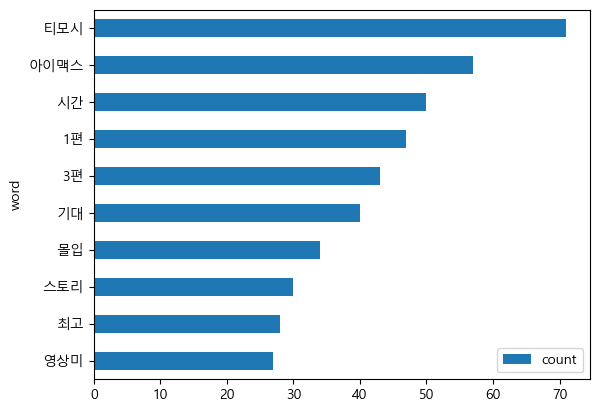

{'티모시': 71, '아이맥스': 57, '시간': 50, '1편': 47, '3편': 43, '기대': 40, '몰입': 34, '스토리': 30, '최고': 28, '영상미': 27, '스케일': 23, '관람': 20, '사막': 19, '연기': 18, '다음': 18, '가입': 18, '사운드': 17, '이해': 16, '배우': 16, '듄1': 15, '몰입감': 15, '모래': 15, '3시간': 15, '내용': 15, '느낌': 15, '리산': 14, '2편': 14, '시작': 14, '세계관': 13, '전개': 13, '파트2': 13, '연출': 13, '압도': 13, '음향': 12, '영상': 12, '감독': 12, '재미': 12, '듄3': 11, '장엄': 11, '타임': 11, '화면': 11, '파트1': 11, '음악': 10, '추천': 10, '이유': 10, '극장': 10, '하나': 9, '이상': 9, '원작': 9, '장면': 9, '전쟁': 9, '이야기': 9, '사람': 9, '반지': 8, '진짜': 8, '배경': 8, '제왕': 8, '볼만': 8, '상영': 8, '만족': 8, '액션': 8, '듄2': 8, '완벽': 8, '거대': 8, '서사시': 8, '스크린': 8, '전편': 7, '러닝타임': 7, '주인공': 7, '중간': 7, '다음편이': 7, '자체': 7, '보세': 7, '러닝': 7, '압도적': 7, '생각': 7, '사랑': 6, '종교': 6, '정도': 6, '적인': 6, '압도적인': 6, '시리즈': 6, '소설': 6, '만큼': 6, '일반': 6, '상영시간': 6, '예매': 6, '보고': 6, '처음': 6, '볼거리': 5, '모래벌레': 5, '마음': 5, '3부': 5, '이것': 5, '우리': 5, '우슬': 5, '뇌브': 5, '스타워즈': 5, '완전': 5, '벌레': 5, '가능': 5, '집중': 5, '전투'

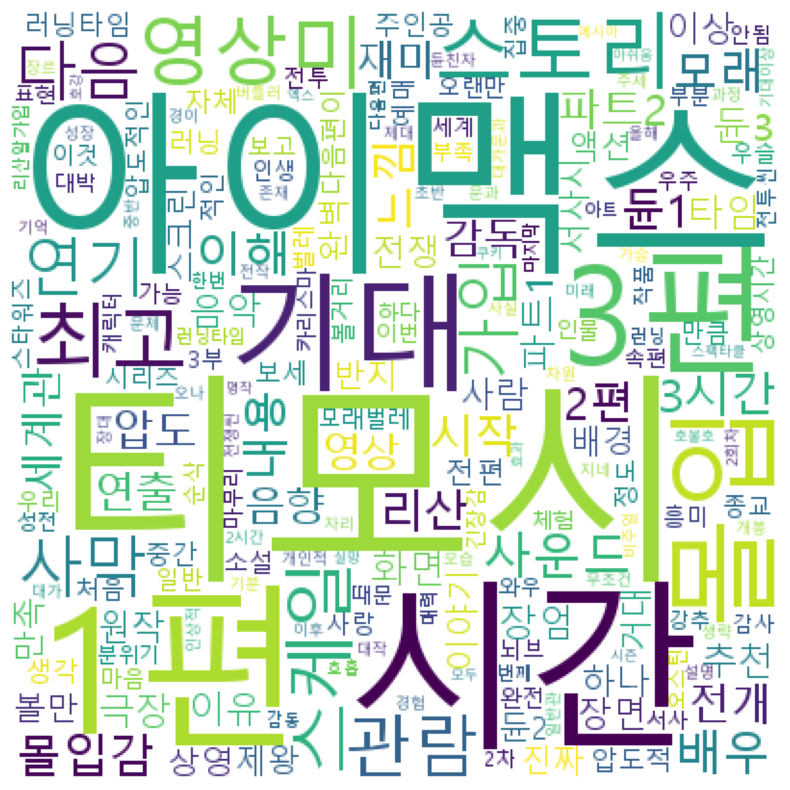

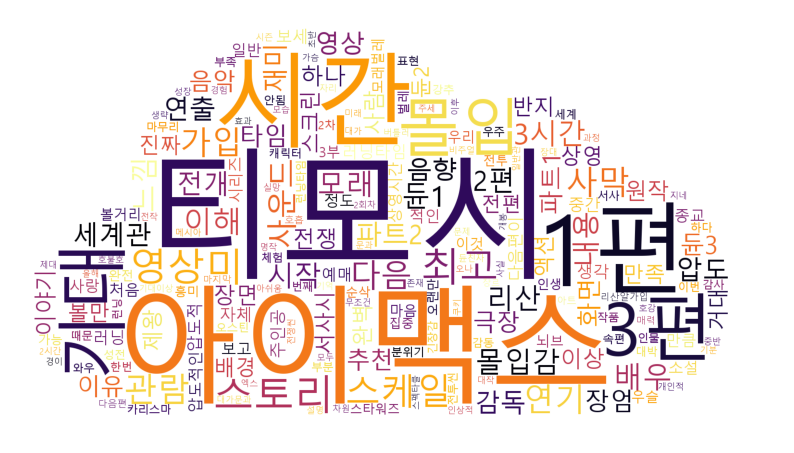

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import konlpy

df = pd.read_csv('D:/2604340036 - 송성민/빅데이터/빅데이터/data/movie1_review.csv')
print(df, '\n')

kkma = konlpy.tag.Kkma()

nouns = df['Review'].apply(kkma.nouns)
print(nouns, '\n')

nouns = nouns.explode()
print(nouns, '\n')

nouns[nouns == '모시'] = '티모시'
nouns[nouns == 'IMAX'] = '아이맥스'
nouns[nouns == '파트3'] = '3편'

df_word = pd.DataFrame({'word' : nouns})
df_word['count'] = df_word['word'].str.len()
df_word = df_word.query('count >= 2')
print(df_word, '\n')

df_word = df_word.groupby('word', as_index = False)
df_word = df_word.count().sort_values('count', ascending = False)
print(df_word, '\n')

del_idx = df_word.loc[df_word.word.isin(['영화', '편이', '영화관', '파트'])].index
df_word = df_word.drop(index = del_idx)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df_top10 = df_word.iloc[:10, :].sort_values('count', ascending = True)
df_top10.plot.barh(x = 'word', y = 'count')
plt.show()

dic_word = df_word.set_index('word').to_dict()['count']
print(dic_word, '\n')

wc = WordCloud(random_state = 123,
               font_path = 'C:/Windows/Fonts/malgun.ttf',
               width = 400,
               height = 400,
               background_color = 'white')

img_wordcloud = wc.generate_from_frequencies(dic_word)

plt.figure(figsize = (10, 10))
plt.axis('off')
plt.imshow(img_wordcloud)
plt.show()

import PIL
import numpy as np

icon = PIL.Image.open('D:/2604340036 - 송성민/빅데이터/빅데이터/data/cloud.png').convert("RGBA")
img = PIL.Image.new(mode = "RGBA", size = icon.size, color = (255, 255, 255))
img.paste(icon, icon)
img = np.array(img)

wc = WordCloud(random_state = 123,
               font_path = 'C:/Windows/Fonts/malgun.ttf',
               width = 400,
               height = 400,
               background_color = 'white',
               mask = img,
               colormap = 'inferno')

img_wordcloud = wc.generate_from_frequencies(dic_word)

plt.figure(figsize = (10, 10))
plt.axis('off')
plt.imshow(img_wordcloud)
plt.show()

                                                Review
0                             "유엔과 한국: 함께 이루는 인류의 꿈"\n
1                                                   \n
2    존경하는 국민 여러분, 존경하는 강창희 국회의장님과 국회의원 여러분, 그리고 주한 ...
3                                                   \n
4    한국과 유엔의 길고 특별한 인연을 생각할 때, 저의 두 번째 임기를 시작하면서 대한...
..                                                 ...
152  저는 유엔 사무총장에 취임한 첫 날부터 솔선수범하며 일신 우일신하는 자세로 지내왔습...
153                                                 \n
154   대한민국의 앞날에 무궁한 영광이 깃들고, 국민 여러분께 만복이 충만하시기를 빕니다.\n
155                                                 \n
156                                     경청해 주셔서 감사합니다.

[157 rows x 1 columns] 

0                                        [유엔, 한국, 인류, 꿈]
1                                                     []
2      [존경, 국민, 여러분, 강, 강창희, 창희, 국회, 장님, 국회의원, 주한, 외교...
3                                                     []
4      [한국, 유엔, 특별, 인연, 생각, 때, 저, 번째, 임기, 시작, 대한, 대한민...
                             

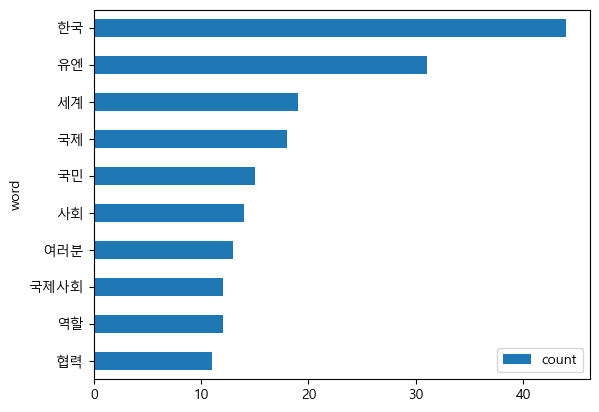

{'한국': 44, '유엔': 31, '세계': 19, '국제': 18, '국민': 15, '사회': 14, '여러분': 13, '역할': 12, '국제사회': 12, '협력': 11, '평화': 10, '개발': 10, '노력': 10, '기대': 9, '유엔사무총장': 9, '세계적': 9, '기여': 8, '귀빈': 8, '지도자': 8, '내외귀빈': 8, '경험': 8, '미래': 8, '문제': 8, '존경': 8, '희망': 8, '내외': 8, '목표': 7, '증진': 7, '주의': 7, '인권': 7, '필요': 7, '적인': 6, '사업': 6, '국회의원': 6, '민국': 6, '경제': 6, '도움': 6, '특별': 6, '가능': 5, '변화': 5, '인류': 5, '자리': 5, '성공': 5, '국회': 5, '이행': 5, '보편적': 5, '중요': 5, '민주주의': 5, '취임': 5, '지속': 5, '민주': 5, '지원': 5, '달성': 5, '평가': 5, '여성': 5, '이상': 4, '이야기': 4, '방문': 4, '적극적': 4, '감사': 4, '정부': 4, '주도': 4, '모든': 4, '주민': 4, '사례': 4, '계속': 4, '추구': 4, '세대': 4, '2015': 4, '2015년': 4, '한반도': 4, '확대': 4, '강화': 4, '확신': 4, '활동': 4, '기회': 4, '회의': 4, '대외': 4, '대처': 4, '대화': 4, '북한': 4, '분야': 4, '개선': 4, '분쟁': 4, '최근': 4, '시기': 4, '실현': 4, '가지': 4, '안전': 4, '결과': 4, '유지': 4, '의지': 3, '발전': 3, '열망': 3, '시민': 3, '성장': 3, '불가능': 3, '교훈': 3, '영광': 3, '국제적': 3, '감축': 3, '모범': 3, '국회의': 3, '번째': 3, '시작': 3, '선진': 3, '사무':

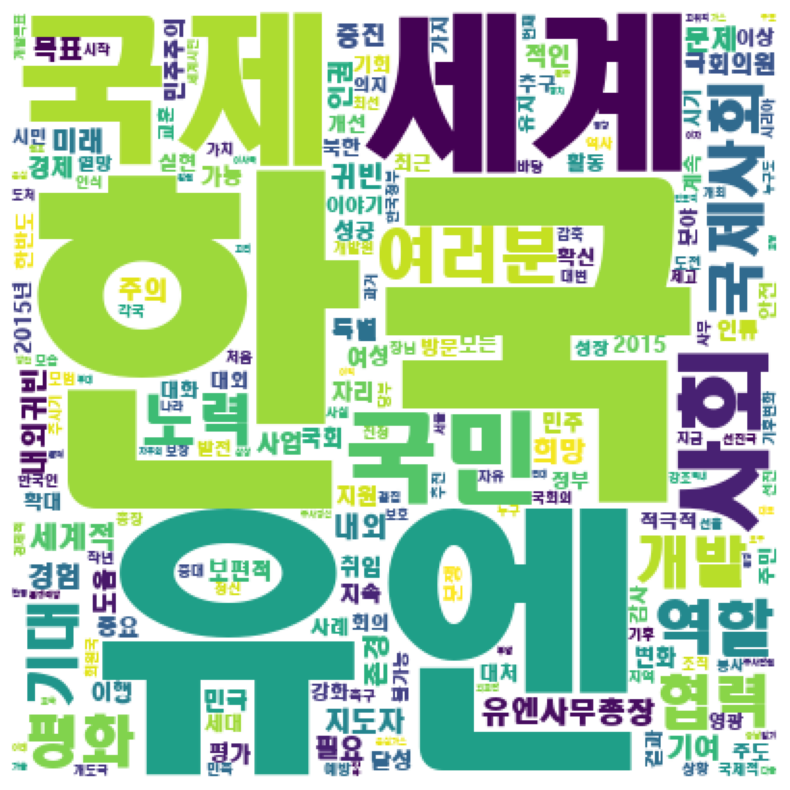

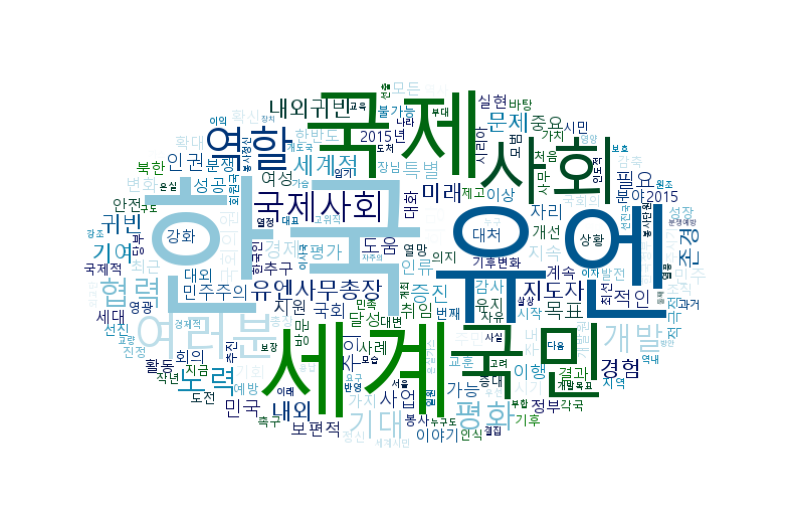

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import konlpy

with open("D:/2604340036 - 송성민/빅데이터/빅데이터/data/반기문_국회_연설문.txt", 'r', encoding='utf-8') as f:
    lines = f.readlines()

# 리스트를 데이터프레임으로 변환
df = pd.DataFrame(lines, columns=['Review'])
print(df, '\n')

kkma = konlpy.tag.Kkma()

nouns = df['Review'].apply(kkma.nouns)
print(nouns, '\n')

nouns = nouns.explode()
print(nouns, '\n')

nouns[nouns == '대한민국'] = '한국'
nouns[nouns == 'UN'] = '유엔'
nouns[nouns == '사무총장'] = '유엔사무총장'

df_word = pd.DataFrame({'word' : nouns})
df_word['count'] = df_word['word'].str.len()
df_word = df_word.query('count >= 2')
print(df_word, '\n')

df_word = df_word.groupby('word', as_index = False)
df_word = df_word.count().sort_values('count', ascending = False)
print(df_word, '\n')

del_idx = df_word.loc[df_word.word.isin(['오늘', '이번', '우리', '사람', '국가', '생각', '말씀', '하나', '부분', '대한'])].index
df_word = df_word.drop(index = del_idx)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df_top10 = df_word.iloc[:10, :].sort_values('count', ascending = True)
df_top10.plot.barh(x = 'word', y = 'count')
plt.show()

dic_word = df_word.set_index('word').to_dict()['count']
print(dic_word, '\n')

wc = WordCloud(random_state = 123,
               font_path = 'C:/Windows/Fonts/HMKMRHD.TTF',
               width = 400,
               height = 400,
               background_color = 'white')

img_wordcloud = wc.generate_from_frequencies(dic_word)

plt.figure(figsize = (10, 10))
plt.axis('off')
plt.imshow(img_wordcloud)
plt.show()

import PIL
import numpy as np

icon = PIL.Image.open('D:/2604340036 - 송성민/빅데이터/빅데이터/data/oval.png').convert("RGBA")
img = PIL.Image.new(mode = "RGBA", size = icon.size, color = (255, 255, 255))
img.paste(icon, icon)
img = np.array(img)

wc = WordCloud(random_state = 123,
               font_path = 'C:/Windows/Fonts/malgun.ttf',
               width = 400,
               height = 400,
               background_color = 'white',
               mask = img,
               colormap = 'ocean')

img_wordcloud = wc.generate_from_frequencies(dic_word)

plt.figure(figsize = (10, 10))
plt.axis('off')
plt.imshow(img_wordcloud)
plt.show()


<class 'pandas.DataFrame'>
RangeIndex: 4622 entries, 0 to 4621
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction         4622 non-null   int64  
 1   quantity            4622 non-null   int64  
 2   Item                4622 non-null   str    
 3   choice_description  3376 non-null   str    
 4   item_price          4622 non-null   float64
dtypes: float64(1), int64(2), str(2)
memory usage: 462.1 KB
None 

   Transaction  quantity                                   Item  item_price
0            1         1           Chips and Fresh Tomato Salsa        2.39
1            1         1                                   Izze        3.39
2            1         1                       Nantucket Nectar        3.39
3            1         1  Chips and Tomatillo-Green Chili Salsa        2.39
4            2         2                           Chicken Bowl       16.98
50
                              Item  

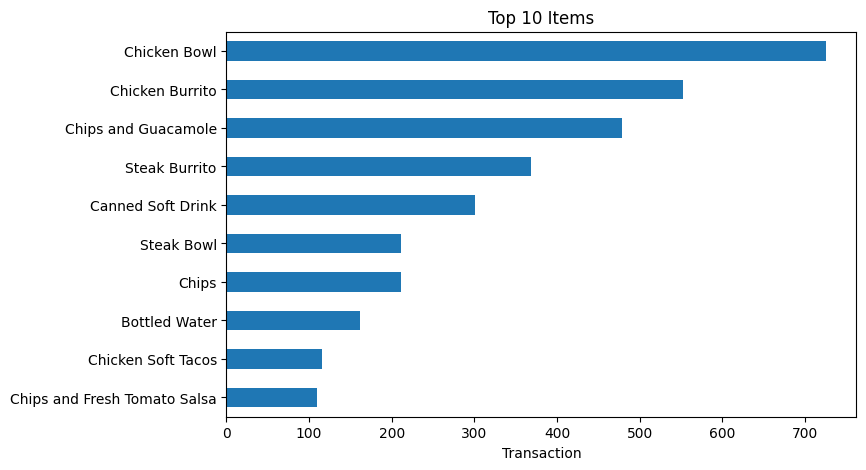

Transaction
1       [Chips and Fresh Tomato Salsa, Izze, Nantucket...
2                                          [Chicken Bowl]
3                           [Chicken Bowl, Side of Chips]
4                       [Steak Burrito, Steak Soft Tacos]
5                    [Steak Burrito, Chips and Guacamole]
                              ...                        
1830                      [Steak Burrito, Veggie Burrito]
1831                [Carnitas Bowl, Chips, Bottled Water]
1832            [Chicken Soft Tacos, Chips and Guacamole]
1833                                      [Steak Burrito]
1834                                 [Chicken Salad Bowl]
Name: Item, Length: 1834, dtype: object 

[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]] 

   6 Pack Soft Drink  Barbacoa Bowl  Barba

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import association_rules, apriori
from mlxtend.preprocessing import TransactionEncoder

df = pd.read_csv('D:/2604340036 - 송성민/빅데이터/빅데이터/data/chipotle.csv')

print(df.info(), '\n')
print(df.iloc[:, [0, 1, 2, 4]].head())

print(len(df['Item'].unique()))
temp = df[df.item_price == df.item_price.max()]
temp = temp[['Item', 'item_price']].drop_duplicates()
print(temp, '\n')

temp = df[df.item_price == df.item_price.min()]
temp = temp[['Item', 'item_price']].drop_duplicates()
print(temp, '\n')

print(len(df['Transaction'].unique()))

sales_quantity = df.groupby('Item').count()
sales_quantity = sales_quantity.sort_values('Transaction', ascending = False)
print(sales_quantity['Transaction'], '\n')

top_ten = sales_quantity.sort_values('Transaction').tail(10)
top_ten = top_ten['Transaction']

top_ten.plot.barh(xlabel = 'Transaction',
                  ylabel = '',
                  title = 'Top 10 Items',
                  figsize = (9, 5))
plt.subplots_adjust(left = 0.2)
plt.show()

temp = df[['Transaction', 'Item']].drop_duplicates()
temp = temp.groupby('Transaction')['Item'].apply(list)
print(temp, '\n')

te = TransactionEncoder()
trans_matrix = te.fit(temp).transform(temp)
print(trans_matrix, '\n')

basket = pd.DataFrame(trans_matrix, columns = te.columns_)
print(basket.head(), '\n')

freq_item = apriori(df = basket, min_support = 0.01, use_colnames = True)
print(freq_item , '\n')

rules = association_rules(df = freq_item, metric = 'lift', min_threshold = 1,
                          num_itemsets = len(basket))
rules.sort_values('confidence', ascending = False, inplace = True)
print(rules.head(10), '\n')
print(rules.iloc[0, :].transpose())